In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift))

sys.path.append('/home/cosweeney/code/Fits/')

sys.path.append('/home/cosweeney/code/Fits/Jocond')

from JoCond.jocond.losvd import *
from JoCond.jocond.cat import *
from JoCond.jocond.hgcf import *
from JoCond.jocond.myconfig import*

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

from skewt_scipy.skewt import skewt

0.6777 74.71913613009617 74.71913613009617


In [4]:
Rvirs, Mvirs, mbins = compute_bin_virial_R_M('/spiff/cosweeney/Tables/halo_pair_cat_final2_HD.hdf5')

# radial bins
r_edges = np.linspace(5, 50, (50-5)+1)
r_cens = (r_edges[1:]+r_edges[:-1])/2.0 

R_edges = np.linspace(5, 15, (15-5)+1)
R_cens = (R_edges[1:]+R_edges[:-1])/2.0 

massbin edges, in h^-1 sol mass: [8.00020227e+13 1.22732852e+14 1.88287152e+14 2.88855436e+14
 4.43139440e+14 6.79829904e+14 1.60000000e+15]


In [6]:
# bin sim data in bins of R (r2d)
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

vpeclos  = []
vphyslos = []
rlos_R = []
R_R = []
M_R = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):
        rel_R = hdf[f'R/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_R, R_edges) - 1
        
        for i in range(len(R_cens)):
            mask = bin_indices == i
            vpeclos.append(vpec[mask])
            vphyslos.append(vphys[mask])
            rlos_R.append(rel_rlos[mask])
            R_R.append(rel_R[mask])
            M_R.append(Mvir[mask])

In [7]:
# bin sim data in bins of r3d
vel_path = '/spiff/cosweeney/simulations/MDPL2/data/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

vpeclos  = []
vphyslos = []
rlos_r = []
r_r = []
M_r = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(len(Mvirs)):
        rel_r = hdf[f'r/{k}'][()]
        rel_rlos = hdf[f'rlos/{k}'][()]
        vpec = hdf[f'vpeclos/{k}'][()]
        vphys = hdf[f'vphyslos/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_r, r_edges) - 1
        
        for i in range(len(r_cens)):
            mask = bin_indices == i
            vpeclos.append(vpec[mask])
            vphyslos.append(vphys[mask])
            rlos_r.append(rel_rlos[mask])
            r_r.append(rel_r[mask])
            M_r.append(Mvir[mask])

In [8]:
def skewed_t_pdf(x, xi, omega, alpha, nu):
    """
    Azzalini & Capitanio skewed t-distribution PDF
    
    Parameters:
    xi: location parameter
    omega: scale parameter (> 0)
    alpha: skewness parameter
    nu: degrees of freedom (> 0)
    """
    # Standardize
    z = (x - xi) / omega
    
    # Student's t PDF
    t_pdf = t.pdf(z, df=nu)
    
    # Student's t CDF with modified argument
    t_cdf = t.cdf(alpha * z * np.sqrt((nu + 1) / (nu + z**2)), df=nu + 1)
    
    # Skewed t PDF
    pdf = (2 / omega) * t_pdf * t_cdf
    
    return pdf

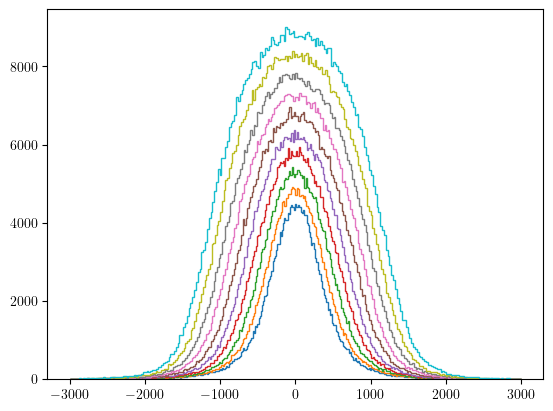

In [10]:
for i in range(10):
    test_hist = plt.hist(vphyslos[i], bins='auto', range=[-3000, 3000], histtype='step')

In [ ]:
# fit P(vlos|r)

rpars = np.zeros((len(Mvirs), len(r_cens), 4))
rcovs = np.zeros((len(Mvirs), len(r_cens), 4, 4))

for k in range(len(Mvirs)):
    for i in range(len(r_cens)):
        index = i + k*len(r_cens)

        hist, bins = np.histogram(vpeclos, bins='auto', range=[-3000, 3000], density=True)
        cens = 0.5*(bins[1:]+bins[:-1])

        p, c = curve_fit(skewed_t_pdf, cens, hist, p0=[])
